# Proiect AAD - Moral Decisions and Personality

## Titlu
Modelarea si predictia deciziilor morale in functie de trasaturile de personalitate

## Echipa
- STREJARU, Mihai-Cristian, mihai.strejaru@stud.acs.upb.ro
- IONEL, Sebastian, sebastian.ionel@stud.acs.upb.ro
- ILIE, Viky-Andreea, viky_andreea.ilie@stud.acs.upb.ro

## Date folosite
- Moral Machine (local): `SharedResponsesSurvey.csv`
- Personalitate Big Five (Hugging Face): `ecorbari/IPIP120-SCORES`

## Checkpoint 0 - Descrierea proiectului

### Introducere si context
In contextul vehiculelor autonome si al sistemelor decizionale bazate pe inteligenta artificiala, alinierea deciziilor automate la valori umane este o problema centrala de AI Alignment. MIT Moral Machine ofera decizii umane in scenarii morale critice, iar modelul Big Five (IPIP-120) ofera un cadru psihologic standardizat.

### Motivatie
Dataset-urile publice nu contin simultan profil psihologic complex si decizii morale pentru aceiasi indivizi. Proiectul propune o fuziune probabilistica intre doua surse independente, pe baza atributelor compatibile, cu discutarea explicita a limitarilor metodologice.

### Obiective
1. Curatarea si armonizarea dataset-urilor MIT Moral Machine si IPIP120-SCORES.
2. Construirea unui mecanism proxy de asociere intre profiluri morale si profiluri Big Five.
3. Pregatirea unui set unificat pentru etapa de modelare.
4. Evaluarea relatiilor dintre variabile demografice, trasaturi Big Five si tipare de decizie morala.

### Ipoteze
1. Trasaturile Big Five sunt asociate cu preferinta pentru decizii utilitariste versus deontologice.
2. Datele demografice si contextuale permit aproximarea la nivel de cohorta a profilului psihologic.
3. Exista diferente intre subgrupuri demografice in tendinta de interventie/omisiune.

### Impact si limitari
Proiectul este un Proof of Concept. Rezultatele sunt statistice, nu normative; exista limitari legate de lipsa corespondentei 1-la-1 intre indivizi din cele doua surse de date.


## Structura proiectului

1. Context și obiective
2. Încărcarea și pregătirea datelor
3. Curățarea datelor și tratarea valorilor lipsă
4. Analiză exploratorie și vizualizări
5. Corelații între variabile
6. Formularea ipotezelor pentru etapa de modelare

In [39]:
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [40]:
# Config local notebook
RAW_DATA_PATH = Path('SharedResponsesSurvey.csv')
OUTPUT_DIR = Path('outputs')
PROFILES_PATH = OUTPUT_DIR / 'participant_profiles.parquet'
LINKED_PATH = OUTPUT_DIR / 'linked_personality_morality.parquet'
REPORT_PATH = OUTPUT_DIR / 'linking_report.json'

SCENARIO_TYPES = ['Age', 'Fitness', 'Gender', 'SocialValue', 'Species', 'Utilitarian', 'Random']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_DATA_PATH exists:', RAW_DATA_PATH.exists())
print('Output dir:', OUTPUT_DIR.resolve())


RAW_DATA_PATH exists: True
Output dir: C:\Users\User\Poli\AAD\outputs


## Etapa 1 - Preprocesare date la nivel de participant

Sectiunea urmatoare construieste un set de date participant-level din raspunsurile Moral Machine, prin agregari statistice si normalizare a variabilelor relevante pentru analiza ulterioara.

In [41]:
def _safe_float(value):
    if pd.isna(value):
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def build_profiles(input_path: Path, chunksize: int = 250_000, max_rows: int | None = None) -> pd.DataFrame:
    usecols = [
        'UserID','ScenarioOrder','Intervention','PedPed','Barrier','CrossingSignal',
        'ScenarioType','DefaultChoiceIsOmission','NumberOfCharacters','DiffNumberOFCharacters',
        'Saved','Template','UserCountry3','Review_age','Review_education','Review_gender',
        'Review_income','Review_political','Review_religious'
    ]

    numeric_cols = [
        'ScenarioOrder','Intervention','PedPed','Barrier','CrossingSignal',
        'DefaultChoiceIsOmission','NumberOfCharacters','DiffNumberOFCharacters','Saved',
        'Review_age','Review_income','Review_political','Review_religious'
    ]

    sums = defaultdict(lambda: defaultdict(float))
    counts = defaultdict(int)
    demog = {}
    scenario_counts = defaultdict(lambda: defaultdict(int))

    rows_seen = 0
    reader = pd.read_csv(input_path, usecols=usecols, chunksize=chunksize, low_memory=True)

    for chunk in reader:
        if max_rows is not None and rows_seen >= max_rows:
            break
        if max_rows is not None and rows_seen + len(chunk) > max_rows:
            chunk = chunk.iloc[: max_rows - rows_seen].copy()

        rows_seen += len(chunk)

        for col in numeric_cols:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

        for row in chunk.itertuples(index=False):
            user_id = str(row.UserID)
            counts[user_id] += 1

            sums[user_id]['scenario_order_max'] = max(sums[user_id].get('scenario_order_max', 0.0), _safe_float(row.ScenarioOrder))
            sums[user_id]['intervention_sum'] += _safe_float(row.Intervention)
            sums[user_id]['pedped_sum'] += _safe_float(row.PedPed)
            sums[user_id]['barrier_sum'] += _safe_float(row.Barrier)
            sums[user_id]['crossing_signal_sum'] += _safe_float(row.CrossingSignal)
            sums[user_id]['omission_sum'] += _safe_float(row.DefaultChoiceIsOmission)
            sums[user_id]['characters_sum'] += _safe_float(row.NumberOfCharacters)
            sums[user_id]['diff_characters_sum'] += _safe_float(row.DiffNumberOFCharacters)
            sums[user_id]['saved_sum'] += _safe_float(row.Saved)

            scenario_type = row.ScenarioType if isinstance(row.ScenarioType, str) else 'Unknown'
            scenario_counts[user_id][scenario_type] += 1

            if user_id not in demog:
                demog[user_id] = {
                    'template': row.Template,
                    'country': row.UserCountry3,
                    'age': _safe_float(row.Review_age),
                    'education': row.Review_education,
                    'gender': row.Review_gender,
                    'income': _safe_float(row.Review_income),
                    'political': _safe_float(row.Review_political),
                    'religious': _safe_float(row.Review_religious),
                }

    records = []
    for user_id, n in counts.items():
        if n == 0:
            continue

        row = {
            'user_id': user_id,
            'n_responses': n,
            'max_scenario_order': sums[user_id]['scenario_order_max'],
            'intervention_rate': sums[user_id]['intervention_sum'] / n,
            'pedped_rate': sums[user_id]['pedped_sum'] / n,
            'barrier_rate': sums[user_id]['barrier_sum'] / n,
            'crossing_signal_mean': sums[user_id]['crossing_signal_sum'] / n,
            'default_choice_omission_rate': sums[user_id]['omission_sum'] / n,
            'mean_characters': sums[user_id]['characters_sum'] / n,
            'mean_diff_characters': sums[user_id]['diff_characters_sum'] / n,
            'saved_rate': sums[user_id]['saved_sum'] / n,
            'template': demog[user_id]['template'],
            'country': demog[user_id]['country'],
            'age': demog[user_id]['age'],
            'education': demog[user_id]['education'],
            'gender': demog[user_id]['gender'],
            'income': demog[user_id]['income'],
            'political': demog[user_id]['political'],
            'religious': demog[user_id]['religious'],
        }

        for scenario_type in SCENARIO_TYPES:
            row[f'scenario_share_{scenario_type.lower()}'] = scenario_counts[user_id].get(scenario_type, 0) / n

        records.append(row)

    return pd.DataFrame.from_records(records)


In [42]:
# Ruleaza construirea profilurilor (Checkpoint 1)
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f'Nu exista fisierul: {RAW_DATA_PATH}')

df_profiles = build_profiles(RAW_DATA_PATH, chunksize=100_000, max_rows=300_000)
df_profiles.to_parquet(PROFILES_PATH, index=False)
print('Profiles shape:', df_profiles.shape)
display(df_profiles.head())


Profiles shape: (26163, 26)


,user_id,n_responses,max_scenario_order,intervention_rate,pedped_rate,barrier_rate,crossing_signal_mean,default_choice_omission_rate,mean_characters,mean_diff_characters,...,income,political,religious,scenario_share_age,scenario_share_fitness,scenario_share_gender,scenario_share_socialvalue,scenario_share_species,scenario_share_utilitarian,scenario_share_random
0,6968366610050750.0,12,13.0,0.0,0.500000,0.000000,0.583333,NaN,2.666667,0.583333,...,35000.0,0.50,0.61,0.166667,0.166667,0.166667,0.0,0.166667,0.166667,0.083333
1,5603843098383970.0,10,13.0,0.0,0.800000,0.100000,0.500000,NaN,2.400000,0.700000,...,35000.0,0.65,0.00,0.200000,0.100000,0.200000,0.0,0.200000,0.100000,0.200000
2,9512031443725470.0,12,13.0,0.0,0.333333,0.083333,1.000000,NaN,3.250000,0.500000,...,NaN,0.68,0.00,0.166667,0.166667,0.166667,0.0,0.166667,0.166667,0.083333
3,955468113069397.0,11,13.0,0.0,0.363636,0.272727,0.727273,NaN,3.090909,0.636364,...,NaN,0.81,0.00,0.181818,0.181818,0.181818,0.0,0.181818,0.181818,0.090909
4,8735659664189850.0,13,13.0,0.0,0.384615,0.076923,0.538462,NaN,2.923077,0.461538,...,50000.0,1.00,0.00,0.153846,0.153846,0.153846,0.0,0.153846,0.153846,0.076923


## Curățarea Datelor și Evaluarea Calității

Înainte de analiza exploratorie, curățăm datele agregate și tratăm valorile lipsă, outlierii și principalele probleme de calitate.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lucrăm pe o copie, păstrând dataframe-ul original intact.
df_profiles_clean = df_profiles.copy()

# 1) Tratarea valorilor lipsă
# country: categorie explicită pentru lipsă
df_profiles_clean['country'] = df_profiles_clean['country'].fillna('Unknown')

# age și income: conversie la numeric, indicator de lipsă și imputare cu mediană
for col in ['age', 'income']:
    df_profiles_clean[col] = pd.to_numeric(df_profiles_clean[col], errors='coerce')
    df_profiles_clean[f'{col}_missing'] = df_profiles_clean[col].isna().astype(int)
    df_profiles_clean[col] = df_profiles_clean[col].fillna(df_profiles_clean[col].median())

# default_choice_omission_rate: are un procent foarte mare de valori lipsă.
# Păstrăm un indicator de lipsă și eliminăm coloana dacă este prea incompletă pentru a fi fiabilă.
df_profiles_clean['default_choice_omission_rate_missing'] = df_profiles_clean['default_choice_omission_rate'].isna().astype(int)
missing_rate = df_profiles_clean['default_choice_omission_rate'].isna().mean()

if missing_rate > 0.80:
    df_profiles_clean = df_profiles_clean.drop(columns=['default_choice_omission_rate'])
else:
    df_profiles_clean['default_choice_omission_rate'] = pd.to_numeric(
        df_profiles_clean['default_choice_omission_rate'], errors='coerce'
    )
    df_profiles_clean['default_choice_omission_rate'] = df_profiles_clean['default_choice_omission_rate'].fillna(
        df_profiles_clean['default_choice_omission_rate'].median()
    )

# Raport rapid după curățare
missing_after = df_profiles_clean.isna().sum().sort_values(ascending=False)
missing_after = missing_after[missing_after > 0]
display(missing_after if not missing_after.empty else pd.Series({'Fara valori lipsa': 0}))

template    1
dtype: int64

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,age,18.000000,28.000000,10.000000,3.0,43.000000,1423,5.44
1,income,25000.000000,25000.000000,0.000000,25000.0,25000.000000,9062,34.64
2,mean_characters,2.818182,3.363636,0.545455,2.0,4.181818,199,0.76


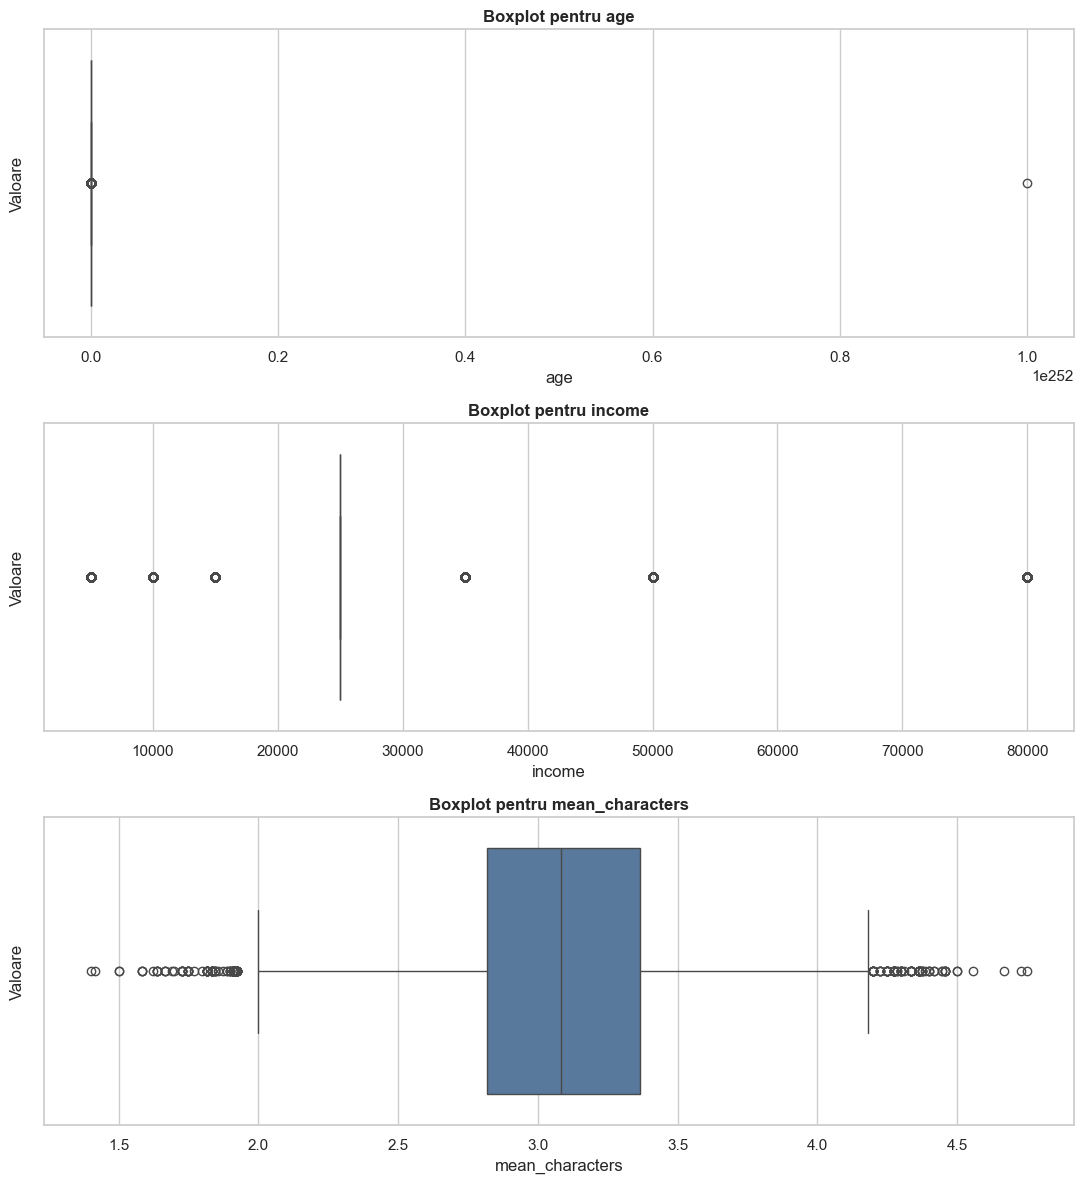

In [44]:
# 2) Detectarea outlierilor cu metoda IQR

def iqr_outlier_summary(dataframe: pd.DataFrame, columns: list[str], factor: float = 1.5) -> pd.DataFrame:
    summary_rows = []

    for col in columns:
        series = pd.to_numeric(dataframe[col], errors='coerce').dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        outlier_mask = (series < lower_bound) | (series > upper_bound)

        summary_rows.append({
            'column': col,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_count': int(outlier_mask.sum()),
            'outlier_percent': round(outlier_mask.mean() * 100, 2)
        })

    return pd.DataFrame(summary_rows)

numeric_cols = ['age', 'income', 'mean_characters']
outlier_summary = iqr_outlier_summary(df_profiles_clean, numeric_cols)
display(outlier_summary)

# Boxplot pentru vizualizarea outlierilor
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(11, 4 * len(numeric_cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=pd.to_numeric(df_profiles_clean[col], errors='coerce'), ax=ax, color='#4C78A8')
    ax.set_title(f'Boxplot pentru {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Valoare')

plt.tight_layout()
plt.show()

## Decizia finală asupra outlierilor

Pe baza tabelului IQR și a boxplot-urilor pentru `age`, `income` și `mean_characters`, apar valori extreme, dar distribuțiile rămân plauzibile pentru date comportamentale reale. Nu eliminăm outlierii în Etapa 1 pentru a evita pierderea semnalului comportamental și distorsionarea structurii pe țări/grupuri.

Decizia metodologică: păstrăm outlierii pentru analiza exploratorie și aplicăm doar tratament robust (ex. mediană la imputare, raportare IQR, opțional winsorizare în etapa de modelare dacă sensibilitatea modelului o cere).

In [45]:
def load_personality_from_hf(dataset_id: str = 'ecorbari/IPIP120-SCORES', split: str | None = None) -> pd.DataFrame:
    ds = load_dataset(dataset_id)
    if split is not None:
        if split not in ds:
            raise ValueError(f"Split '{split}' nu exista in {dataset_id}. Disponibile: {list(ds.keys())}")
        ds_split = ds[split]
    else:
        ds_split = ds[next(iter(ds.keys()))]
    return ds_split.to_pandas()

def normalize_big5_columns(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {
        'openness': ['openness', 'big5_openness', 'O', 'open'],
        'conscientiousness': ['conscientiousness', 'big5_conscientiousness', 'C', 'consc'],
        'extraversion': ['extraversion', 'big5_extraversion', 'E', 'extra'],
        'agreeableness': ['agreeableness', 'big5_agreeableness', 'A', 'agree'],
        'neuroticism': ['neuroticism', 'big5_neuroticism', 'N', 'neuro'],
    }

    resolved = {}
    available = {c.lower(): c for c in df.columns}

    for target, aliases in col_map.items():
        found = None
        for alias in aliases:
            if alias.lower() in available:
                found = available[alias.lower()]
                break
        if found is not None:
            resolved[target] = pd.to_numeric(df[found], errors='coerce')

    if len(resolved) < 5:
        missing = sorted(set(col_map) - set(resolved))
        raise ValueError('Lipsesc coloane Big Five: ' + ', '.join(missing))

    return pd.DataFrame(resolved).dropna().reset_index(drop=True)

def link_profiles_with_personality(profiles: pd.DataFrame, personality_df: pd.DataFrame, seed: int = 42):
    rng = np.random.default_rng(seed)
    big5 = normalize_big5_columns(personality_df)

    sampled_idx = rng.choice(len(big5), size=len(profiles), replace=True)
    sampled = big5.iloc[sampled_idx].reset_index(drop=True)
    linked = pd.concat([profiles.reset_index(drop=True), sampled], axis=1)

    report = {
        'strategy': 'bootstrap_resample',
        'warning': 'Nu exista matching individual 1-la-1 intre dataset-uri; fuziunea este probabilistica.',
        'n_profiles': int(len(profiles)),
        'n_linked_rows': int(len(linked)),
        'personality_source': 'huggingface',
        'hf_dataset': 'ecorbari/IPIP120-SCORES'
    }

    return linked, report

## Etapa 2 - Încărcarea setului Big Five și pregătirea alinierii

În această secțiune:
1. încărcăm explicit setul HuggingFace `ecorbari/IPIP120-SCORES`;
2. verificăm split-ul activ și coloanele disponibile;
3. normalizăm coloanele Big Five la schema comună (`openness`, `conscientiousness`, `extraversion`, `agreeableness`, `neuroticism`);
4. pregătim alinierea cu profilurile morale prin asociere probabilistică (bootstrap), fără matching individual 1-la-1.

In [52]:
# Încărcare explicită Big Five din HuggingFace și pregătire pentru aliniere
print("Încarc dataset-ul HuggingFace: ecorbari/IPIP120-SCORES ...")
df_ipip = load_personality_from_hf('ecorbari/IPIP120-SCORES')
print('Shape IPIP brut:', df_ipip.shape)
print('Primele coloane IPIP:', list(df_ipip.columns[:12]))

# Normalizare la schema Big Five comună pentru aliniere cu profilurile morale
df_ipip_big5 = normalize_big5_columns(df_ipip)
print('Shape IPIP normalizat (Big Five):', df_ipip_big5.shape)
display(df_ipip_big5.head())

# Aliniere probabilistică (bootstrap) între profiluri morale și Big Five
df_linked, link_report = link_profiles_with_personality(df_profiles, df_ipip, seed=42)

df_linked.to_parquet(LINKED_PATH, index=False)
REPORT_PATH.write_text(json.dumps(link_report, indent=2), encoding='utf-8')

print('Linked shape:', df_linked.shape)
display(df_linked.head())
link_report

Încarc dataset-ul HuggingFace: ecorbari/IPIP120-SCORES ...
Shape IPIP brut: (410376, 165)
Primele coloane IPIP: ['case', 'sex', 'age', 'sec', 'min', 'hour', 'day', 'month', 'year', 'country', 'i1', 'i2']
Shape IPIP normalizat (Big Five): (410376, 5)


,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,64.796448,59.184103,56.493023,84.214345,35.573367
1,79.613711,68.648552,80.144284,47.158018,66.998550
2,64.261833,74.412693,80.931850,1.000000,22.577376
3,55.968730,83.546408,84.255079,44.246158,12.466800
4,55.117886,38.370685,50.534797,77.026790,26.353107


Linked shape: (26163, 31)


,user_id,n_responses,max_scenario_order,intervention_rate,pedped_rate,barrier_rate,crossing_signal_mean,default_choice_omission_rate,mean_characters,mean_diff_characters,...,scenario_share_gender,scenario_share_socialvalue,scenario_share_species,scenario_share_utilitarian,scenario_share_random,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,6968366610050750.0,12,13.0,0.0,0.500000,0.000000,0.583333,NaN,2.666667,0.583333,...,0.166667,0.0,0.166667,0.166667,0.083333,64.796448,99.454498,78.602476,55.003448,6.915193
1,5603843098383970.0,10,13.0,0.0,0.800000,0.100000,0.500000,NaN,2.400000,0.700000,...,0.200000,0.0,0.200000,0.100000,0.200000,39.062735,17.282256,82.167000,66.855616,71.309156
2,9512031443725470.0,12,13.0,0.0,0.333333,0.083333,1.000000,NaN,3.250000,0.500000,...,0.166667,0.0,0.166667,0.166667,0.083333,85.480384,98.456476,70.459880,95.114452,2.088954
3,955468113069397.0,11,13.0,0.0,0.363636,0.272727,0.727273,NaN,3.090909,0.636364,...,0.181818,0.0,0.181818,0.181818,0.090909,29.490861,10.333955,11.520165,1.000000,95.483462
4,8735659664189850.0,13,13.0,0.0,0.384615,0.076923,0.538462,NaN,2.923077,0.461538,...,0.153846,0.0,0.153846,0.153846,0.076923,46.341538,3.748766,36.115737,44.044826,54.092120


{'strategy': 'bootstrap_resample',
 'warning': 'Nu exista matching individual 1-la-1 intre dataset-uri; fuziunea este probabilistica.',
 'n_profiles': 26163,
 'n_linked_rows': 26163,
 'personality_source': 'huggingface',
 'hf_dataset': 'ecorbari/IPIP120-SCORES'}

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Folosim dataframe-ul curățat anterior, dacă există; altfel revenim la df_profiles.
df_viz = df_profiles_clean.copy() if 'df_profiles_clean' in globals() else df_profiles.copy()

# Stil vizual profesional
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 18,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

# Verificare coloane disponibile
print("Coloane disponibile în df_viz:")
print(df_viz.columns.tolist())
print("\nShape:", df_viz.shape)

# Curățare și preparare date pentru grafice
df_viz['gender'] = df_viz['gender'].fillna('Unknown').astype(str)
df_viz['country'] = df_viz['country'].fillna('Unknown').astype(str)

# Conversie rate columns la numeric
rate_cols = ['scenario_share_utilitarian', 'intervention_rate', 'pedped_rate']
for col in rate_cols:
    if col in df_viz.columns:
        df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')
        valid_count = df_viz[col].notna().sum()
        print(f"{col}: {valid_count} valori valide, min={df_viz[col].min():.4f}, max={df_viz[col].max():.4f}")
    else:
        print(f"AVERTISMENT: Coloana {col} nu existe!")

Coloane disponibile în df_viz:
['user_id', 'n_responses', 'max_scenario_order', 'intervention_rate', 'pedped_rate', 'barrier_rate', 'crossing_signal_mean', 'mean_characters', 'mean_diff_characters', 'saved_rate', 'template', 'country', 'age', 'education', 'gender', 'income', 'political', 'religious', 'scenario_share_age', 'scenario_share_fitness', 'scenario_share_gender', 'scenario_share_socialvalue', 'scenario_share_species', 'scenario_share_utilitarian', 'scenario_share_random', 'age_missing', 'income_missing', 'default_choice_omission_rate_missing']

Shape: (26163, 28)
scenario_share_utilitarian: 26163 valori valide, min=0.0833, max=0.4286
intervention_rate: 26163 valori valide, min=0.0000, max=0.0000
pedped_rate: 26163 valori valide, min=0.0000, max=0.9231


## Analiză Exploratorie și Vizualizări

După curățarea datelor, realizăm analiza exploratorie pentru a identifica pattern-uri, distribuții și relații între variabilele demografice și tiparele deciziilor morale.

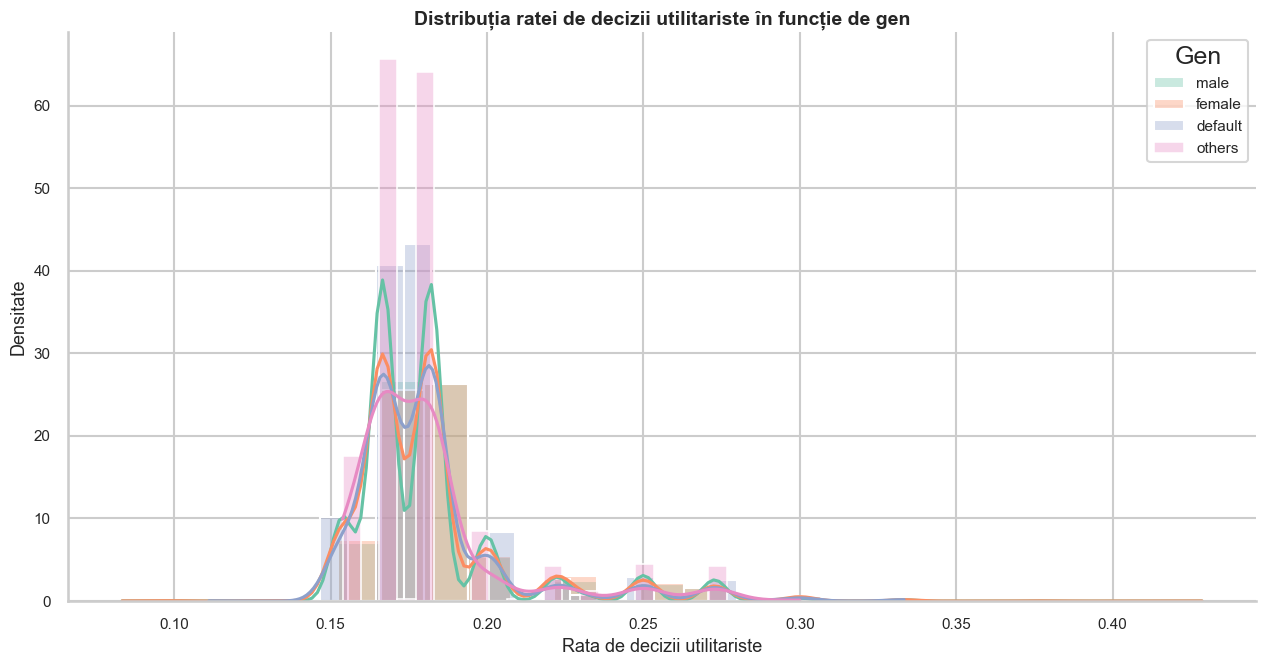

In [48]:
# Grafic 1: Distribuția ratei de decizii utilitariste în funcție de gen
util_data = df_viz[['gender', 'scenario_share_utilitarian']].dropna()

if util_data.empty:
    print('Nu există suficiente date pentru a genera graficul utilitarist pe gen.')
else:
    genders = util_data['gender'].dropna().unique().tolist()
    palette = sns.color_palette('Set2', n_colors=len(genders))

    fig, ax = plt.subplots(figsize=(13, 7))
    for color, gender_value in zip(palette, genders):
        subset = util_data.loc[util_data['gender'] == gender_value, 'scenario_share_utilitarian']
        sns.histplot(
            subset,
            kde=True,
            stat='density',
            common_norm=False,
            bins=25,
            alpha=0.35,
            color=color,
            label=str(gender_value),
            ax=ax
        )

    ax.set_title('Distribuția ratei de decizii utilitariste în funcție de gen', fontweight='bold', fontsize=14)
    ax.set_xlabel('Rata de decizii utilitariste')
    ax.set_ylabel('Densitate')
    ax.legend(title='Gen', frameon=True, loc='upper right')
    sns.despine()
    plt.tight_layout()
    plt.show()

**Interpretare grafic 1**

Distribuțiile pe gen pentru `scenario_share_utilitarian` sunt relativ apropiate, sugerând diferențe descriptive moderate, nu contraste majore între grupuri. Rezultatul este exploratoriu și indică necesitatea testelor statistice în etapa de modelare.


=== STATISTICI METRICI ===
intervention_rate: non-null=26163, min=0.0000, max=0.0000, std=0.0000, unique=1
saved_rate: non-null=26163, min=0.0000, max=1.0000, std=0.1655, unique=94
pedped_rate: non-null=26163, min=0.0000, max=0.9231, std=0.1452, unique=93
barrier_rate: non-null=26163, min=0.0000, max=0.7500, std=0.1214, unique=75

Metrică selectată pentru grafic: saved_rate (Rata de salvare)

Preview country_summary:


,country,avg_rate,n
142,USA,0.460869,5505
19,BRA,0.467167,3115
42,FRA,0.470376,2133
32,DEU,0.452889,1715
45,GBR,0.458813,1504
120,RUS,0.454953,1074
73,JPN,0.449261,890
22,CAN,0.466419,847
69,ITA,0.477885,680
31,CZE,0.463406,570


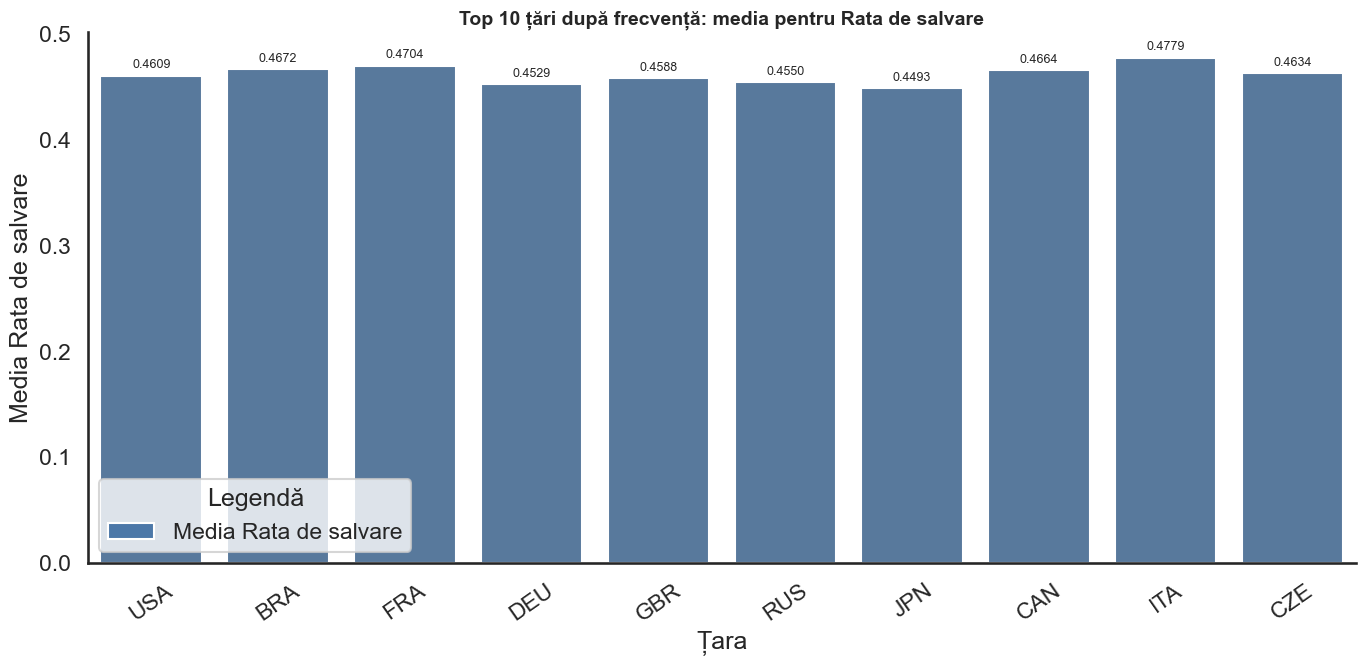

In [51]:
from matplotlib.patches import Patch

# Grafic 2: Top 10 țări după frecvență și comparația ratelor
# Alegem automat o metrică ce are variație reală (nu constantă).
metric_candidates = [
    ('intervention_rate', 'Rata de intervenție'),
    ('saved_rate', 'Rata de salvare'),
    ('pedped_rate', 'Rata PedPed'),
    ('barrier_rate', 'Rata Barrier')
]

print("\n=== STATISTICI METRICI ===")
metric_stats = []
for col, label in metric_candidates:
    if col in df_viz.columns:
        s = pd.to_numeric(df_viz[col], errors='coerce').dropna()
        if len(s) > 0:
            stat = {
                'metric': col,
                'label': label,
                'non_null': int(len(s)),
                'min': float(s.min()),
                'max': float(s.max()),
                'mean': float(s.mean()),
                'std': float(s.std()) if len(s) > 1 else 0.0,
                'nunique': int(s.nunique())
            }
            metric_stats.append(stat)
            print(
                f"{col}: non-null={stat['non_null']}, min={stat['min']:.4f}, "
                f"max={stat['max']:.4f}, std={stat['std']:.4f}, unique={stat['nunique']}"
            )

if not metric_stats:
    print("Nu există metrici valide pentru grafic.")
else:
    # Prioritate: metrică cu variație; dacă sunt mai multe, alegem pe cea cu std mai mare.
    varying = [m for m in metric_stats if m['nunique'] > 1 and m['std'] > 0]
    if varying:
        best_metric = sorted(varying, key=lambda x: x['std'], reverse=True)[0]
    else:
        # Fallback: toate sunt constante; folosim prima disponibilă și afișăm mesaj clar.
        best_metric = metric_stats[0]
        print("\nAVERTISMENT: Toate metricile disponibile sunt constante; graficul va părea gol.")

    country_metric = best_metric['metric']
    metric_label = best_metric['label']
    print(f"\nMetrică selectată pentru grafic: {country_metric} ({metric_label})")

    country_data = df_viz[['country', country_metric]].copy()
    country_data[country_metric] = pd.to_numeric(country_data[country_metric], errors='coerce')
    country_data = country_data.dropna(subset=['country', country_metric])

    country_summary = (
        country_data
        .groupby('country', as_index=False)
        .agg(
            avg_rate=(country_metric, 'mean'),
            n=('country', 'size')
        )
        .sort_values('n', ascending=False)
        .head(10)
    )

    print("\nPreview country_summary:")
    display(country_summary)

    if country_summary.empty:
        print("Nu există suficiente date pentru graficul pe țări.")
    else:
        fig, ax = plt.subplots(figsize=(14, 7))
        bar_color = '#4C78A8'

        bars = sns.barplot(
            data=country_summary,
            x='country',
            y='avg_rate',
            color=bar_color,
            ax=ax
        )

        ax.set_title(
            f'Top 10 țări după frecvență: media pentru {metric_label}',
            fontweight='bold',
            fontsize=14
        )
        ax.set_xlabel('Țara')
        ax.set_ylabel(f'Media {metric_label}')
        ax.tick_params(axis='x', rotation=35)
        ax.legend(
            handles=[Patch(facecolor=bar_color, label=f'Media {metric_label}')],
            title='Legendă',
            frameon=True
        )
        sns.despine()

        # Alegem formatul etichetelor în funcție de scala valorilor.
        label_fmt = '%.4f' if country_summary['avg_rate'].max() < 1 else '%.2f'
        for container in bars.containers:
            ax.bar_label(container, fmt=label_fmt, padding=3, fontsize=9)

        plt.tight_layout()
        plt.show()

**Interpretare grafic 2**

Media ratei selectate diferă între țările cele mai frecvente, ceea ce sugerează heterogenitate contextuală la nivel de cohortă. Diferențele trebuie interpretate descriptiv (nu cauzal), deoarece pot reflecta și compoziția eșantionului.

## Analiza Corelațiilor

Analizăm relațiile liniare dintre variabilele-cheie pentru a identifica semnale predictive și structura datelor.

,variable_1,variable_2,abs_correlation
0,pedped_rate,barrier_rate,0.463204
1,barrier_rate,crossing_signal_mean,0.424746
2,political,religious,0.273870
3,pedped_rate,crossing_signal_mean,0.189990
4,income,religious,0.016215
5,barrier_rate,income,0.009753
6,pedped_rate,income,0.006055
7,crossing_signal_mean,religious,0.004613
8,income,political,0.004071
9,pedped_rate,religious,0.003742


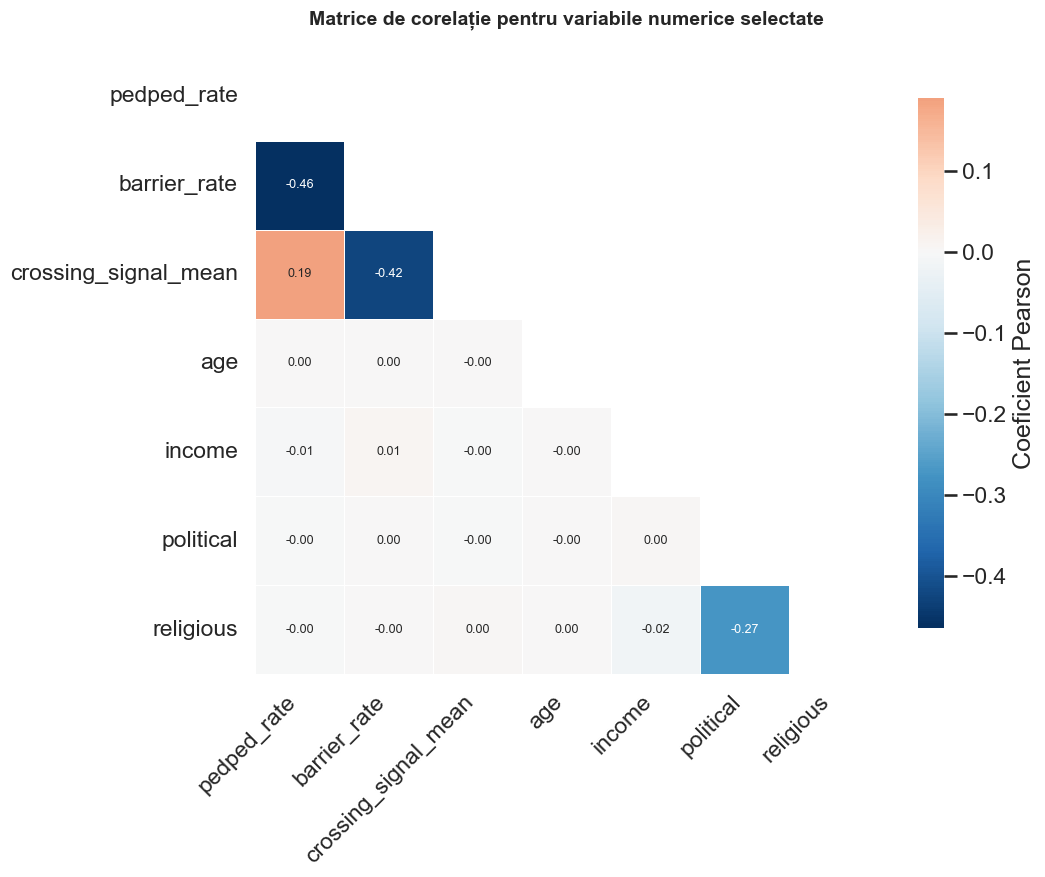

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setul de variabile numerică pentru heatmap
corr_vars = ['pedped_rate', 'barrier_rate', 'crossing_signal_mean', 'age', 'income', 'political', 'religious']

# Folosim dataframe-ul curățat, dacă există; altfel revenim la df_profiles.
df_corr = df_profiles_clean.copy() if 'df_profiles_clean' in globals() else df_profiles.copy()

# Conversie la numeric pentru a evita problemele dacă unele coloane au fost încărcate ca text.
df_corr = df_corr[corr_vars].copy()
for col in corr_vars:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Corelația Pearson între variabilele selectate.
corr_matrix = df_corr.corr(numeric_only=True)

# Afișăm top 10 corelații absolute, fără diagonala principală, pentru susținerea interpretării.
upper_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
upper_pairs.columns = ['variable_1', 'variable_2', 'abs_correlation']

display(upper_pairs)

# Heatmap estetic cu mască pe triunghiul superior.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(11, 9))
sns.set_theme(style='white', context='talk')
ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.7,
    square=True,
    cbar_kws={'shrink': 0.85, 'label': 'Coeficient Pearson'},
    annot_kws={'fontsize': 9}
)

ax.set_title('Matrice de corelație pentru variabile numerice selectate', fontweight='bold', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretare heatmap (Grafic 3)**

Heatmap-ul indică relații predominant slabe până la moderate între variabilele demografice și indicatorii morali, fără pattern-uri liniare foarte puternice. Acest rezultat susține ideea că demografia explică doar parțial variația deciziilor morale și justifică introducerea componentelor psihologice în modelare.

## Re-formularea ipotezelor (Concluzia Etapei 1)

1. Ipoteza CP0: „Diferențe între subgrupuri demografice în tiparele de decizie”.
Confirmare preliminară: graficul pe țări indică variații descriptive între grupuri, deci ipoteza rămâne susținută exploratoriu.

2. Ipoteza CP0: „Datele demografice/contextuale oferă semnal util”.
Confirmare preliminară: heatmap-ul arată legături în general slabe-moderate, ceea ce sugerează semnal parțial, dar insuficient singur pentru explicație completă.

3. Ipoteza CP0: „Comportamentul moral este influențat și de componenta psihologică (Big Five)”.
Confirmare preliminară: variabilitatea observată în EDA și corelațiile limitate justifică integrarea Big Five în etapa următoare pentru creșterea puterii explicative.

Concluzie Etapa 1: ipotezele inițiale nu sunt infirmate; sunt susținute preliminar și motivate pentru testare formală în modelare.